In [176]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import os
import matplotlib.mlab as mlab
from scipy.signal import iirnotch, lfilter, freqz, butter, welch
from prettytable import PrettyTable

folder_path =[]
d = []
type = 'Normal'  # 'Normal' or 'Aggressive'
folder_path = fr"data\sub{1}\{type}\txt"
d = (os.listdir(folder_path))
name = ["Right Bicep","Right Tricep","Left Bicep","Left Tricep","Right Thigh","Right Hamstring","Left Thigh","Left Hamstring"]





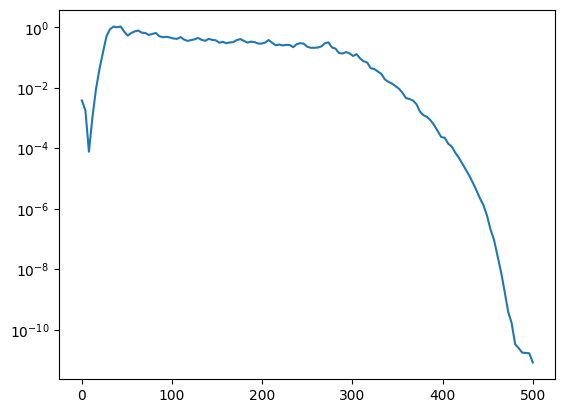

In [197]:
move = d[7]
file = move
folder_path = fr"data\sub{1}\{type}\txt"
df = pd.read_csv(folder_path + "\\" + file, sep = "\t", header = None, names=name)
Fs = 1000

b_notch,a_notch = iirnotch(50,30,Fs)
b_band, a_band = butter(4,[30/(Fs/2),300/(Fs/2)], 'band')

f_notch, h_notch = freqz(b_notch,a_notch)
f_band, h_band = freqz(b_band,a_band)

b_comb = np.convolve(b_notch,b_band)
a_comb = np.convolve(a_notch,a_band)

f_comv, h_comb = freqz(b_comb,a_comb)
y = lfilter(b_comb,a_comb,df["Right Bicep"])


f, Pxx = welch(y, fs=Fs, nperseg=256, noverlap=0.5*256)
plt.plot(f, Pxx)
plt.yscale('log')

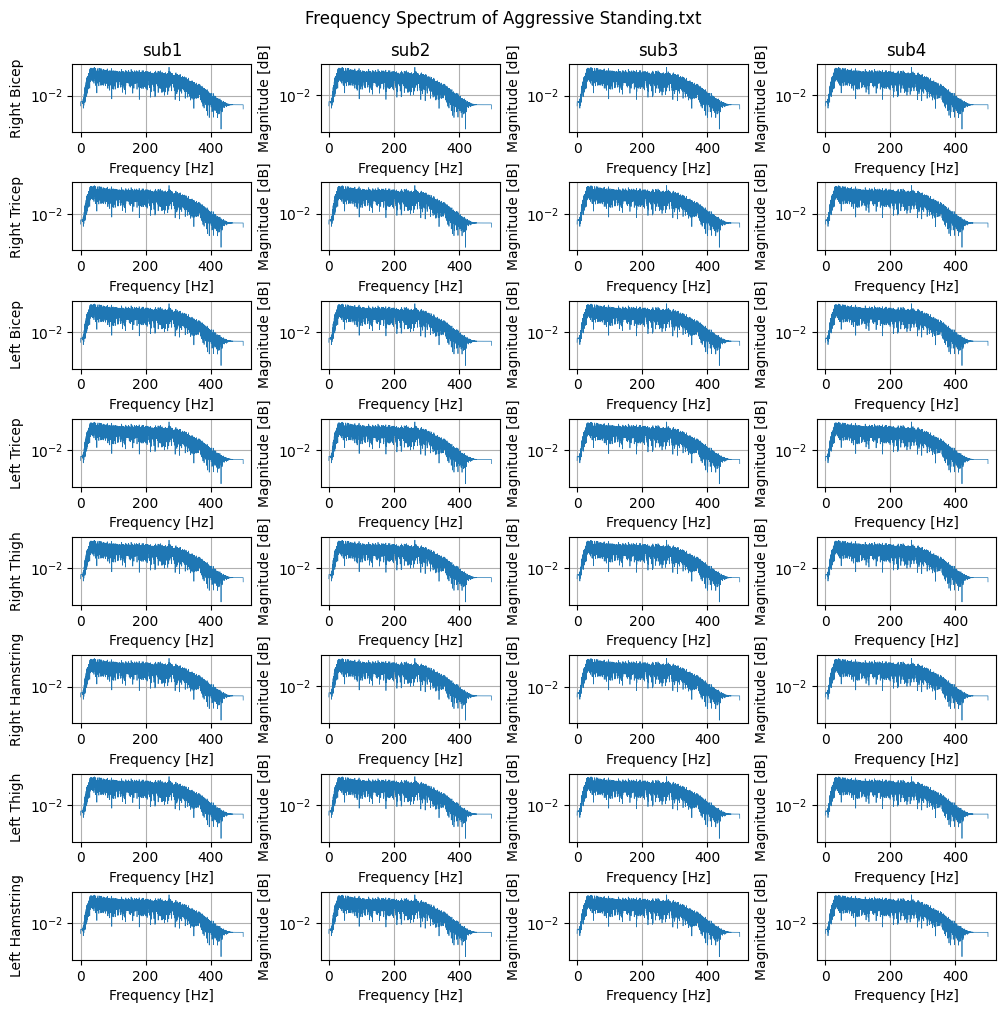

In [198]:
fig, axes = plt.subplots(8,4, figsize=(10,10))
signal_mean = np.zeros(shape=(8,4))
skib = np.zeros(shape=(1,8))
for i in range(1,5):
    file = move
    folder_path = fr"data\sub{i}\{type}\txt"
    df = pd.read_csv(folder_path + "\\" + file, sep = "\t", header = None, names=name)

    Fs = 1000
    T = 1/Fs
    L = len(df)
    t = np.arange(0, len(df))*T
    f = Fs*np.arange(0,L/2)/L

    b_notch,a_notch = iirnotch(50,30,Fs)
    b_band, a_band = butter(4,[30/(Fs/2),300/(Fs/2)], 'band')

    f_notch, h_notch = freqz(b_notch,a_notch)
    f_band, h_band = freqz(b_band,a_band)

    b_comb = np.convolve(b_notch,b_band)
    a_comb = np.convolve(a_notch,a_band)

    f_comv, h_comb = freqz(b_comb,a_comb)
    c = 0
    tmp = []
    for j in name:
        Y = np.fft.fft(y)
        P2 = abs(Y/L)
        P1 = P2[0:L//2+1]
        signal_mean[c][i-1] = np.mean(np.abs(P1))
        tmp.append(np.mean(np.abs(P1)))
        if len(P1) != len(f):
            P1 = P1[:-1]
        P1[1:-1] = 2*P1[1:-1]
        axes[c, i-1].plot(f,P1,linewidth=0.5)
        axes[c, i-1].grid("minor")
        if i == 1:
            axes[c, i-1].set_ylabel(j)
        else:
            axes[c, i-1].set_ylabel("Magnitude [dB]")
        if c == 0:
            axes[c, i-1].set_title(f"sub{i}")
        axes[c, i-1].set_xlabel("Frequency [Hz]")
        axes[c, i-1].set_yscale('log')
        c += 1
    skib = np.vstack((skib,tmp))
fig.suptitle(f"Frequency Spectrum of Aggressive {file}", y=1)
plt.tight_layout(pad=0.5)
plt.show()

    


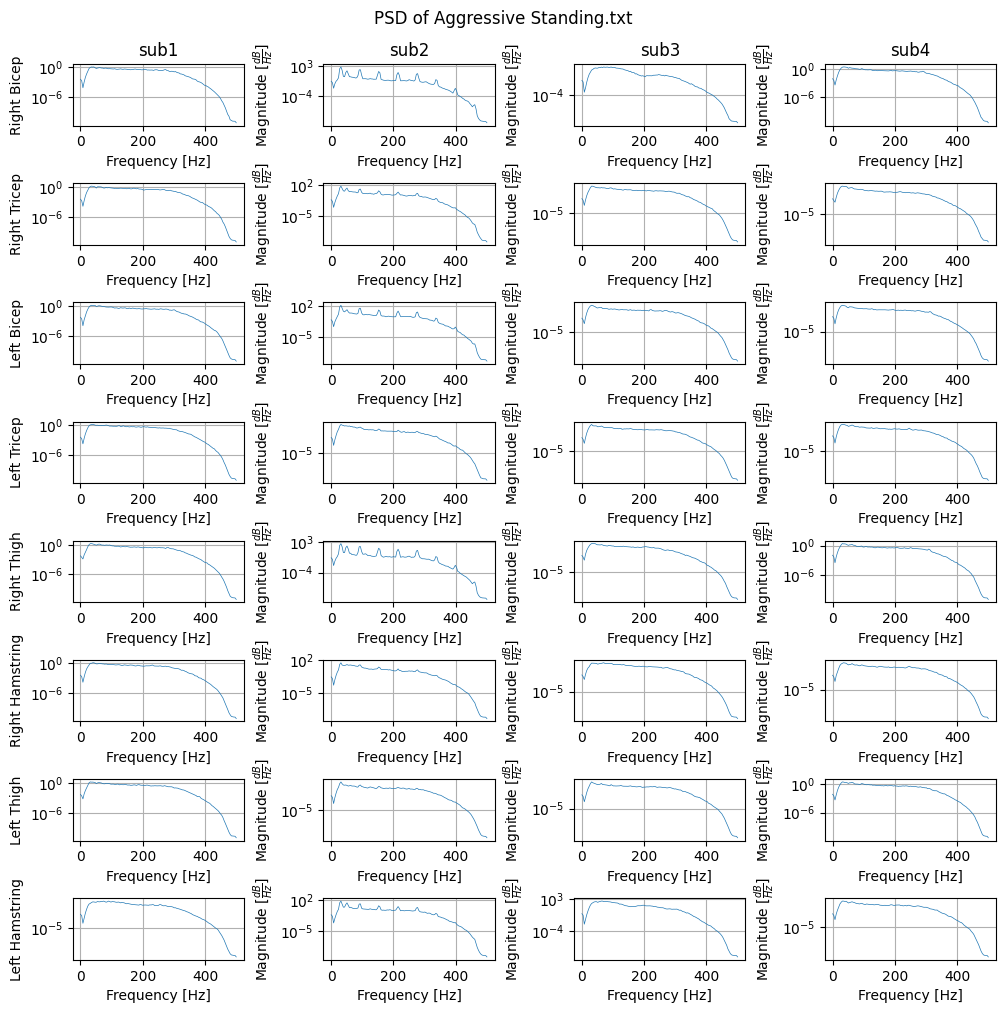

In [199]:
fig_PSD, axes_PSD = plt.subplots(8,4, figsize=(10,10))
signal_mean = np.zeros(shape=(8,4))
Peak = np.zeros(shape=(1,8))
Power = np.zeros(shape=(1,8))
MPF = np.zeros(shape=(1,8))
for i in range(1,5):
    file = move
    folder_path = fr"data\sub{i}\{type}\txt"
    df = pd.read_csv(folder_path + "\\" + file, sep = "\t", header = None, names=name)

    Fs = 1000
    T = 1/Fs
    L = len(df)
    t = np.arange(0, len(df))*T
    f = Fs*np.arange(0,L/2)/L

    b_notch,a_notch = iirnotch(50,30,Fs)
    b_band, a_band = butter(4,[30/(Fs/2),300/(Fs/2)], 'band')

    f_notch, h_notch = freqz(b_notch,a_notch)
    f_band, h_band = freqz(b_band,a_band)

    b_comb = np.convolve(b_notch,b_band)
    a_comb = np.convolve(a_notch,a_band)

    f_comv, h_comb = freqz(b_comb,a_comb)
    c = 0
    tmp = []
    tmp_power = [] 
    tmp_mpf = []
    for j in name:
        y = lfilter(b_comb,a_comb,df[j])
        nper = len(y)
        f_PSD, Pxx_PSD = welch(y, fs=Fs, nperseg=256, noverlap=0.5*256)
        tmp.append(f_PSD[np.argmax(Pxx_PSD)])
        axes_PSD[c, i-1].plot(f_PSD, Pxx_PSD,linewidth=0.5)
        axes_PSD[c, i-1].grid("minor")
        if i == 1:
            axes_PSD[c, i-1].set_ylabel(j)
        else:
            axes_PSD[c, i-1].set_ylabel(r"Magnitude $[\frac{dB}{Hz}]$")
        if c == 0:
            axes_PSD[c, i-1].set_title(f"sub{i}")
        axes_PSD[c, i-1].set_xlabel("Frequency [Hz]")
        axes_PSD[c, i-1].set_yscale('log')
        tmp_power.append(np.sum(Pxx_PSD)*(f_PSD[1]-f_PSD[0]))
        tmp_mpf.append(np.sum(f_PSD*Pxx_PSD)/np.sum(Pxx_PSD))
        c += 1
    Peak = np.vstack((Peak,tmp))
    Power = np.vstack((Power,tmp_power))
    MPF = np.vstack((MPF,tmp_mpf))
fig_PSD.suptitle(f"PSD of Aggressive {file}", y=1)
plt.tight_layout(pad=0.5)
plt.show()

In [200]:
tmp = np.zeros(shape=(8,1))
avg_pow = np.zeros(shape=(8,1))
avg_mpf = np.zeros(shape=(8,1))
for i in range(8):
    tmp[i][0] = np.average(Peak.T[i:i+1,1:])
    avg_pow[i][0] = np.average(Power.T[i:i+1,1:])
    avg_mpf[i][0] = np.average(MPF.T[i:i+1,1:])
print("Peak Frequency")
print(tmp)
print("MPF")
print(avg_mpf)
print("Total Power")
print(avg_pow)


Peak Frequency
[[50.78125  ]
 [32.2265625]
 [32.2265625]
 [33.203125 ]
 [32.2265625]
 [44.921875 ]
 [31.25     ]
 [53.7109375]]
MPF
[[ 98.90122981]
 [ 98.22833074]
 [ 98.07217958]
 [102.40121456]
 [ 98.29002084]
 [106.62931971]
 [110.06718941]
 [ 97.84395523]]
Total Power
[[3632.24015758]
 [ 384.04594435]
 [ 565.9640198 ]
 [ 354.99978535]
 [1519.8101013 ]
 [ 497.47250318]
 [ 202.12085122]
 [5805.82651905]]


In [201]:
for i in range(8):
    print(tmp[i][0])
print()
for i in range(8):
    print(f"{avg_mpf[i][0]:.8f}")
print()
for i in range(8):
    print(f"{avg_pow[i][0]:.8f}")

50.78125
32.2265625
32.2265625
33.203125
32.2265625
44.921875
31.25
53.7109375

98.90122981
98.22833074
98.07217958
102.40121456
98.29002084
106.62931971
110.06718941
97.84395523

3632.24015758
384.04594435
565.96401980
354.99978535
1519.81010130
497.47250318
202.12085122
5805.82651905


In [202]:
print(move)
print(name)

Standing.txt
['Right Bicep', 'Right Tricep', 'Left Bicep', 'Left Tricep', 'Right Thigh', 'Right Hamstring', 'Left Thigh', 'Left Hamstring']


In [203]:
from prettytable import PrettyTable

# Create table
table = PrettyTable()
table.field_names = ["Muscle", "Peak Frequency (Hz)", "Mean Power Frequency (Hz)", "Total Power"]

# Add rows
values = [
    ["Right Bicep", 46.875, 84.25831502, 2435458.37798787],
    ["Right Tricep", 41.9921875, 74.58440142, 441727.35695825],
    ["Left Bicep", 51.7578125, 82.19584576, 2529787.96669049],
    ["Left Tricep", 38.0859375, 71.23535612, 582137.438846],
    ["Right Thigh", 47.8515625, 75.75725344, 1830539.40136595],
    ["Right Hamstring", 36.1328125, 71.26522862, 929620.13216275],
    ["Left Thigh", 41.015625, 80.64036193, 1335580.03678951],
    ["Left Hamstring", 33.203125, 64.82705386, 928482.58616411]
]

for row in values:
    table.add_row(row)

print(table)


+-----------------+---------------------+---------------------------+------------------+
|      Muscle     | Peak Frequency (Hz) | Mean Power Frequency (Hz) |   Total Power    |
+-----------------+---------------------+---------------------------+------------------+
|   Right Bicep   |        46.875       |        84.25831502        | 2435458.37798787 |
|   Right Tricep  |      41.9921875     |        74.58440142        | 441727.35695825  |
|    Left Bicep   |      51.7578125     |        82.19584576        | 2529787.96669049 |
|   Left Tricep   |      38.0859375     |        71.23535612        |  582137.438846   |
|   Right Thigh   |      47.8515625     |        75.75725344        | 1830539.40136595 |
| Right Hamstring |      36.1328125     |        71.26522862        | 929620.13216275  |
|    Left Thigh   |      41.015625      |        80.64036193        | 1335580.03678951 |
|  Left Hamstring |      33.203125      |        64.82705386        | 928482.58616411  |
+-----------------+--

In [204]:
import pandas as pd

# Data
data = {
    "Peak Frequency (Hz)": [46.875, 41.9921875, 51.7578125, 38.0859375, 47.8515625, 36.1328125, 41.015625, 33.203125],
    "Mean Power Frequency (Hz)": [84.25831502, 74.58440142, 82.19584576, 71.23535612, 75.75725344, 71.26522862, 80.64036193, 64.82705386],
    "Total Power": [2435458.37798787, 441727.35695825, 2529787.96669049, 582137.438846, 1830539.40136595, 929620.13216275, 1335580.03678951, 928482.58616411]
}

# Create DataFrame
df = pd.DataFrame(data)

# Print as a table
print(df)


   Peak Frequency (Hz)  Mean Power Frequency (Hz)   Total Power
0            46.875000                  84.258315  2.435458e+06
1            41.992188                  74.584401  4.417274e+05
2            51.757812                  82.195846  2.529788e+06
3            38.085938                  71.235356  5.821374e+05
4            47.851562                  75.757253  1.830539e+06
5            36.132812                  71.265229  9.296201e+05
6            41.015625                  80.640362  1.335580e+06
7            33.203125                  64.827054  9.284826e+05


In [205]:
print(signal_mean)
print()
#print((skib.T)[1:][:])
print(skib.T[:, 1:])

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

[[0.07525456 0.0711946  0.0771329  0.0711946 ]
 [0.07525456 0.0711946  0.0771329  0.0711946 ]
 [0.07525456 0.0711946  0.0771329  0.0711946 ]
 [0.07525456 0.0711946  0.0771329  0.0711946 ]
 [0.07525456 0.0711946  0.0771329  0.0711946 ]
 [0.07525456 0.0711946  0.0771329  0.0711946 ]
 [0.07525456 0.0711946  0.0771329  0.0711946 ]
 [0.07525456 0.0711946  0.0771329  0.0711946 ]]


In [206]:
print(d)

['Bowing.txt', 'Clapping.txt', 'Handshaking.txt', 'Hugging.txt', 'Jumping.txt', 'Running.txt', 'Seating.txt', 'Standing.txt', 'Walking.txt', 'Waving.txt']
